# Optimize Bayesian Optuna

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# 1. Baca data (gunakan header=None karena .data tidak punya nama kolom)
# Gunakan na_values='?' karena data yang hilang ditandai dengan tanda tanya
df_final= pd.read_csv('communities.data', header=None, na_values='?')

df_final.columns = [f"feat_{i}" for i in range(df_final.shape[1])]

# 2. SEPARASI FITUR DAN TARGET
# X hanya mengambil 54 kolom fitur dari GA secara eksplisit
X = df_final[[
    'feat_49', 'feat_54', 'feat_33', 'feat_45', 'feat_32', 'feat_20', 'feat_7', 'feat_46', 
    'feat_43', 'feat_72', 'feat_24', 'feat_37', 'feat_17', 'feat_76', 'feat_27', 'feat_10', 
    'feat_79', 'feat_25', 'feat_123', 'feat_114', 'feat_30', 'feat_116', 'feat_77', 'feat_124', 
    'feat_104', 'feat_107', 'feat_112', 'feat_106', 'feat_119', 'feat_83', 'feat_105', 'feat_126', 
    'feat_91', 'feat_64', 'feat_101', 'feat_115', 'feat_110', 'feat_26', 'feat_56', 'feat_63', 
    'feat_96', 'feat_70', 'feat_87', 'feat_58', 'feat_120', 'feat_84', 'feat_19', 'feat_11', 
    'feat_117', 'feat_97', 'feat_40', 'feat_53', 'feat_81', 'feat_118'
]]
y = df_final['feat_127']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling Data (Sangat penting untuk kestabilan model)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
# ==========================================
# 2. OPTIMASI HYPERPARAMETER DENGAN OPTUNA
# ==========================================
def objective(trial):
    # Ruang pencarian parameter yang disesuaikan untuk data ~500 baris
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'objective': 'reg:squarederror',
        'random_state': 42
    }
    
    model = xgb.XGBRegressor(**param)
    
    # Menggunakan Cross-Validation 5-Fold agar hasil R2 stabil
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2').mean()
    return score

print("Memulai optimasi dengan Optuna (Bayesian Optimization)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # Mencoba 50 kombinasi cerdas

print(f"\nSkor R2 Terbaik dari Optimasi: {study.best_value:.4f}")
print(f"Parameter Terbaik: {study.best_params}")

[I 2026-05-27 18:50:46,413] A new study created in memory with name: no-name-2d707379-ebac-4c97-87c3-a550a570c3df


Memulai optimasi dengan Optuna (Bayesian Optimization)...


[I 2026-05-27 18:50:49,537] Trial 0 finished with value: 0.6507286715962173 and parameters: {'n_estimators': 1318, 'max_depth': 5, 'learning_rate': 0.025415797444780654, 'subsample': 0.8082652819040754, 'colsample_bytree': 0.6389145218894836, 'gamma': 0.4065835019419431, 'reg_lambda': 4.8237637245146345}. Best is trial 0 with value: 0.6507286715962173.
[I 2026-05-27 18:50:51,452] Trial 1 finished with value: 0.6586452451482969 and parameters: {'n_estimators': 551, 'max_depth': 3, 'learning_rate': 0.029648811828581076, 'subsample': 0.746881503451458, 'colsample_bytree': 0.753544646758318, 'gamma': 0.21556525154146533, 'reg_lambda': 5.599272403898613}. Best is trial 1 with value: 0.6586452451482969.
[I 2026-05-27 18:50:55,908] Trial 2 finished with value: 0.6660445780019546 and parameters: {'n_estimators': 781, 'max_depth': 4, 'learning_rate': 0.01823906372716893, 'subsample': 0.8521638104977447, 'colsample_bytree': 0.6250968409249108, 'gamma': 0.03794924714111175, 'reg_lambda': 8.064069


Skor R2 Terbaik dari Optimasi: 0.6687
Parameter Terbaik: {'n_estimators': 536, 'max_depth': 4, 'learning_rate': 0.018369820729204428, 'subsample': 0.799153963089498, 'colsample_bytree': 0.6367055346748716, 'gamma': 0.027687836137335303, 'reg_lambda': 9.539577032923532}


In [4]:
# ==========================================
# 3. TRAINING ULANG MODEL FINAL
# ==========================================
best_params = study.best_params
final_model = xgb.XGBRegressor(**best_params, random_state=42)
final_model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6367055346748716
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [5]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, max_error
import numpy as np

# 6. PREDIKSI DAN EVALUASI
y_pred = final_model.predict(X_test_scaled)

# Existing metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# New metrics
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
max_err = max_error(y_test, y_pred)
min_err = np.min(np.abs(y_test - y_pred)) # Absolute minimum error

In [6]:
print("\n" + "="*30)
print("HASIL EVALUASI MODEL")
print("="*30)
print(f"R-Squared (R2)  : {r2:.4f}")
print(f"Mean Abs Error  : {mae:.4f}")
print(f"Root MSE (RMSE) : {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Max Error: {max_err:.4f}")
print(f"Min Error: {min_err:.4f}")


HASIL EVALUASI MODEL
R-Squared (R2)  : 0.6188
Mean Abs Error  : 0.0881
Root MSE (RMSE) : 0.1351
MAPE: inf%
Max Error: 0.6599
Min Error: 0.0008


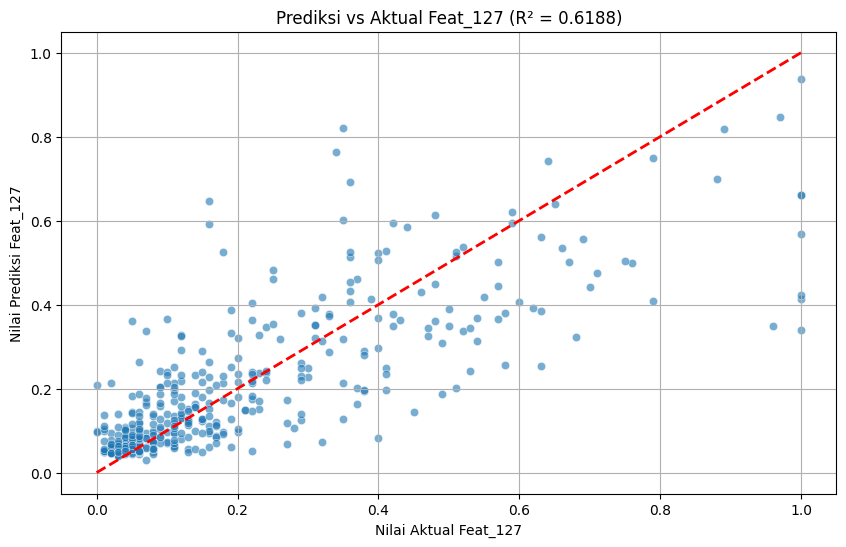

In [7]:
# 7. VISUALISASI HASIL PREDIKSI VS AKTUAL
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Nilai Aktual Feat_127')
plt.ylabel('Nilai Prediksi Feat_127')
plt.title(f'Prediksi vs Aktual Feat_127 (R² = {r2:.4f})')
plt.grid(True)
plt.show()

In [8]:
import pandas as pd

# 7. TABEL PERBANDINGAN AKTUAL VS PREDIKSI
# Membuat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Absolute Error': np.abs(y_test - y_pred),
    'Percentage Error (%)': np.abs((y_test - y_pred) / y_test) * 100
})

# Menampilkan 10 baris pertama untuk pengecekan
print("Comparison Table (First 10 rows):")
print(comparison_df.head(10))

# Opsional: Simpan ke CSV jika diperlukan untuk laporan SEO
# comparison_df.to_csv('model_predictions_comparison.csv', index=False)

Comparison Table (First 10 rows):
      Actual Value  Predicted Value  Absolute Error  Percentage Error (%)
889           0.22         0.176105        0.043895             19.952073
1672          0.04         0.061273        0.021273             53.183434
414           0.10         0.140067        0.040067             40.066668
1599          0.08         0.073923        0.006077              7.595916
849           0.04         0.052248        0.012248             30.619211
1658          0.05         0.074719        0.024719             49.438694
926           0.23         0.237163        0.007163              3.114338
1670          0.48         0.613555        0.133555             27.824011
1448          0.04         0.060454        0.020454             51.134962
1216          0.20         0.271885        0.071885             35.942727


In [9]:
# 8. EXPORT TO EXCEL
# Menentukan nama file
file_name = "c. prediction results M3 dataset C&C UCI ML.xlsx"

# Menyimpan DataFrame ke file Excel
comparison_df.to_excel(file_name, index=False)

print(f"Data successfully saved to {file_name}!")

Data successfully saved to c. prediction results M3 dataset C&C UCI ML.xlsx!


<Figure size 1000x800 with 0 Axes>

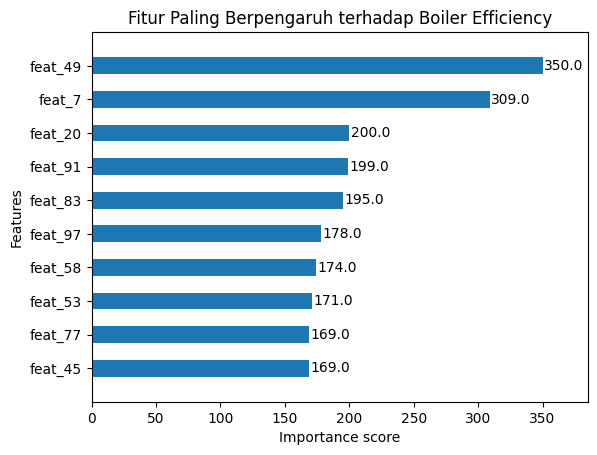

In [10]:
# 8. VISUALISASI FEATURE IMPORTANCE
# Pastikan model tahu nama fiturnya kembali jika sebelumnya menggunakan array hasil scaling
final_model.get_booster().feature_names = X.columns.tolist()

# Plotting
plt.figure(figsize=(10, 8))
xgb.plot_importance(final_model, 
                   importance_type='weight', 
                   max_num_features=10, 
                   grid=False, 
                   height=0.5)
plt.title('Fitur Paling Berpengaruh terhadap Boiler Efficiency')
plt.show()